In [1]:
import re

import catboost
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import shap
from catboost import CatBoostClassifier, Pool
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split


# PR-AUC + Theshold Optimization 모델
* data imbalance가 심하기 때문에 ROC-AUC 기준이 아닌 PR-AUC기준으로 maximize한다.
* `'auto_class_weights'='Balanced'` 옵션을 제거한 뒤 학습한다:
* 1. PR-AUC에 강력한 패널티를 줄 수 있기 때문.
* 2. 확률(`prob`)을 왜곡해 최적의 Threshold를 찾는게 무의미해짐을 방지하기 위해.

## 0. master_df 전처리

In [22]:
orig_df = pd.read_csv('../data/csv/master_df.csv')
master_df = orig_df.copy()
master_df.head(1)

,id,href,price,title,status,content,createdAt,boostedAt,user_dbId,user_nickname,...,boost_diff_seconds,is_boosted,title_len,content_len,has_keyword_new,has_keyword_urgent,price_ratio_to_brand,price_ratio_to_label,days_elapsed,target_n_days
0,11121x6p7597,https://www.daangn.com/kr/buy-sell/%EB%A7%88%E...,22000,마리마켓 트렌치자켓 롤업팬츠 세트 S,Ongoing,"마리마켓 트렌치자켓 롤업팬츠 세트\n베이지 색상\n자켓, 팬츠 둘다 사이즈 S\n미...",2025-10-13 11:00:57+00:00,2026-03-03 12:02:21+00:00,24156105,리본,...,12186084.0,1,20,61,0,0,0.223793,0.122495,142.831007,0.0


In [23]:
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 220688 entries, 0 to 220687
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        220688 non-null  str    
 1   href                      220688 non-null  str    
 2   price                     220688 non-null  int64  
 3   title                     220688 non-null  str    
 4   status                    220688 non-null  str    
 5   content                   220688 non-null  str    
 6   createdAt                 220688 non-null  str    
 7   boostedAt                 220688 non-null  str    
 8   user_dbId                 220688 non-null  int64  
 9   user_nickname             220688 non-null  str    
 10  region_name_from_article  220688 non-null  str    
 11  region_id                 220688 non-null  int64  
 12  region_name               220688 non-null  str    
 13  region_in                 220688 non-null  str    
 14 

In [24]:
master_df['status'].value_counts()

status
Ongoing     146835
Closed       70958
Reserved      2895
Name: count, dtype: int64

In [ ]:
cols_to_drop = [
    'boost_diff_seconds',
    'img_path',
    'review_reason',
    'triage',
    'top3_scores',
    'top3_labels',
    'fine_ratio',
    'fine_margin',
    'fine_conf',
    'coarse_ratio',
    'coarse_margin',
    'coarse_conf',
    'label_conf',
    'fashion_keywords',
    'filled_count',
    'source_file',
    'error',
    'status_detail',
    'imagePath',
    'imageFile',
    'imageUrls',
    'region_in',
    'region_id',
    'region_name_from_article',
]

In [ ]:
clean_df = master_df.drop(cols_to_drop, axis=1)
clean_df.to_csv('../data/csv/clean_df.csv', index=False)
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 220688 entries, 0 to 220687
Data columns (total 33 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    220688 non-null  str    
 1   href                  220688 non-null  str    
 2   price                 220688 non-null  int64  
 3   title                 220688 non-null  str    
 4   status                220688 non-null  str    
 5   content               220688 non-null  str    
 6   createdAt             220688 non-null  str    
 7   boostedAt             220688 non-null  str    
 8   user_dbId             220688 non-null  int64  
 9   user_nickname         220688 non-null  str    
 10  region_name           220688 non-null  str    
 11  crawledAt             220688 non-null  str    
 12  favoriteCount         220688 non-null  int64  
 13  chatCount             220688 non-null  int64  
 14  viewCount             220688 non-null  int64  
 15  sellerTempe

In [2]:
clean_df = pd.read_csv('../data/csv/clean_df.csv')
clean_df.head(1)

,id,href,price,title,status,content,createdAt,boostedAt,user_dbId,user_nickname,...,is_weekend,is_boosted,title_len,content_len,has_keyword_new,has_keyword_urgent,price_ratio_to_brand,price_ratio_to_label,days_elapsed,target_n_days
0,11121x6p7597,https://www.daangn.com/kr/buy-sell/%EB%A7%88%E...,22000,마리마켓 트렌치자켓 롤업팬츠 세트 S,Ongoing,"마리마켓 트렌치자켓 롤업팬츠 세트\n베이지 색상\n자켓, 팬츠 둘다 사이즈 S\n미...",2025-10-13 11:00:57+00:00,2026-03-03 12:02:21+00:00,24156105,리본,...,0,1,20,61,0,0,0.223793,0.122495,142.831007,0.0


In [63]:
n_days = 7  # 예: 7일 이내 판매 여부


# 0. datetime 타입으로 변환 (timezone 제거 혹은 통일)
clean_df['createdAt'] = pd.to_datetime(clean_df['createdAt'], utc=True, format='mixed')
clean_df['boostedAt'] = pd.to_datetime(clean_df['boostedAt'], utc=True, format='mixed')
clean_df['crawledAt'] = pd.to_datetime(clean_df['crawledAt'], utc=True, format='mixed')


# 1. 경과 시간(일) 계산
clean_df['days_elapsed'] = (
    clean_df['crawledAt'] - clean_df['createdAt']
).dt.total_seconds() / (24 * 3600)


# 2. Target 변수 생성 함수
def make_target(row, n):
    # status 컬럼의 '거래완료'를 의미하는 정확한 텍스트 확인 필요 (예: 'Completed', 'Sold' 등)
    is_sold = row['status'] != 'Ongoing'  # 혹은 status_detail 사용

    if is_sold and row['days_elapsed'] <= n:
        return 1  # n일 이내 판매됨
    elif not is_sold and row['days_elapsed'] > n:
        return 0  # n일이 지났는데도 안 팔림
    else:
        return np.nan  # 아직 n일이 안 지났는데 안 팔린 상태 (보류)


clean_df['target_n_days'] = clean_df.apply(lambda x: make_target(x, n_days), axis=1)

# 판별 불가능한(보류된) 데이터 학습에서 제외
train_df = clean_df.dropna(subset=['target_n_days']).copy()
train_df['target_n_days'] = train_df['target_n_days'].astype(int)


In [64]:
# 1. 비율 관련 피처 (조회수 0으로 나누는 것 방지)
train_df['favorite_per_view'] = train_df['favoriteCount'] / (train_df['viewCount'] + 1)
train_df['chat_per_view'] = train_df['chatCount'] / (train_df['viewCount'] + 1)

# 2. 가격 로그 변환 (이상치 영향을 줄이기 위함)
train_df['price_log'] = np.log1p(train_df['price'])

In [ ]:
cols = [
    # --- 판매자 관점에서 볼 수 있는 현재 반응도 데이터 ---
    'status',
    'price',
    'price_log',
    'price_ratio_to_brand',
    'sellerTemperature',
    'title_len',
    'has_keyword_new',
    'title',
    'content',
    'region_name',
    # --- 구매자 관점에서 볼 수 있는 현재 반응도 데이터 ---
    'viewCount',
    'favoriteCount',
    'chatCount',
    'favorite_per_view',
    'chat_per_view',
    'is_boosted',
    'target_n_days',
]

In [66]:
train_df = train_df[cols].copy()

In [67]:
train_df.to_csv('../data/csv/train_df.csv', index=False)

## 1. Seller-side Model

In [ ]:
df = pd.read_csv('../data/csv/train_df_enriched.csv')  # 7일 기준 판매된 상품들 df
df.head(1)

,status,price,price_log,price_ratio_to_brand,sellerTemperature,title_len,has_keyword_new,title,content,region_name,viewCount,favoriteCount,chatCount,favorite_per_view,chat_per_view,is_boosted,target_n_days,brandName
0,Ongoing,22000,9.998843,0.223793,75.9,20,0,마리마켓 트렌치자켓 롤업팬츠 세트 S,"마리마켓 트렌치자켓 롤업팬츠 세트\n베이지 색상\n자켓, 팬츠 둘다 사이즈 S\n미...",역삼1동,168,3,0,0.017751,0.0,1,0,mari market


In [3]:
sell_features = [
    # --- 판매자 관점에서 볼 수 있는 현재 반응도 데이터 ---
    'price',
    'price_ratio_to_brand',
    'sellerTemperature',
    'title_len',
    'has_keyword_new',
    'title',
    'content',
    'region_name',
    'brandName',
]

In [4]:
X_train = df[sell_features]
y_train = df['target_n_days']

cat_features = ['region_name', 'brandName']
text_features = ['title', 'content']

# ---------------------------------------------------------
# [2] Train / Test 분할 및 Pool 생성
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

train_pool = Pool(
    X_train, y_train, cat_features=cat_features, text_features=text_features
)
valid_pool = Pool(
    X_test, y_test, cat_features=cat_features, text_features=text_features
)

In [ ]:
# ==========================================
# 2. Optuna Objective 함수 정의
# ==========================================
def objective(trial):
    # 탐색할 하이퍼파라미터 공간 정의
    param = {
        'iterations': trial.suggest_int('iterations', 500, 1500),  # 학습 횟수
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int(
            'depth', 4, 10
        ),  # 텍스트 모델은 메모리를 많이 쓰므로 최대 8 권장
        'l2_leaf_reg': trial.suggest_float(
            'l2_leaf_reg', 1e-3, 10.0, log=True
        ),  # 정규화
        'random_strength': trial.suggest_float(
            'random_strength', 1e-3, 10.0, log=True
        ),  # 과적합 방지
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'bootstrap_type': 'Bayesian',  # 🌟 수정됨: GPU 환경에서 bagging_temperature 쓸 때 필수
        # 고정 파라미터
        'eval_metric': 'Logloss',
        'random_seed': 42,
        'task_type': 'GPU',
        'verbose': 0,  # 튜닝 중에는 로그 출력 끄기
    }

    model = CatBoostClassifier(**param)

    # 모델 학습 (Early Stopping 적용)
    model.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=50)

    # 검증셋에서 가장 높았던 PR-AUC 점수를 반환
    proba = model.predict_proba(X_test)[:, 1]
    pr_auc = average_precision_score(y_test, proba)

    return pr_auc


# ==========================================
# 3. Optuna Study 실행 (탐색 시작)
# ==========================================
print('🚀 Optuna 하이퍼파라미터 탐색을 시작합니다...')
study = optuna.create_study(direction='maximize')  # PR-AUC는 높을수록 좋으므로 maximize
study.optimize(
    objective, n_trials=100
)  # 우선 30번만 시도 (시간에 따라 50~100번으로 늘려보세요)

print('\n🏆 [Best Trial]')
print(f'최고 PR-AUC 점수: {study.best_value:.4f}')
print('최적의 파라미터:')
for key, value in study.best_params.items():
    print(f'  {key}: {value}')

# ==========================================
# 4. 찾은 최적 파라미터로 최종 모델 학습 및 평가
# ==========================================
print('\n🔥 찾은 최적의 파라미터로 최종 모델을 학습합니다...')
best_params = study.best_params

# 고정 파라미터 다시 추가
best_params.update(
    {
        'eval_metric': 'Logloss',
        'random_seed': 42,
        'task_type': 'GPU',
        'verbose': 50,  # 최종 학습이므로 로그 출력
    }
)

final_model = CatBoostClassifier(**best_params)
final_model.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=50)

# 최종 평가
preds = final_model.predict(X_test)
proba = final_model.predict_proba(X_test)[:, 1]

average_precision = average_precision_score(y_test, proba)
print('\n✅ [최종 모델 평가 지표]')
print(classification_report(y_test, preds))
print(f'PR-AUC: {average_precision:.4f}')

# ==========================================
# 5. Permutation Importance 계산 (최종 1회)
# ==========================================
print('\n📊 Permutation Importance 계산 중... (시간이 조금 소요됩니다)')
X_test_sample = X_test.sample(n=10000, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

# 텍스트 피처가 있으므로 Pool 형태로 묶어서 에러 방지 (필요 시)
sample_pool = Pool(
    X_test_sample, y_test_sample, cat_features=cat_features, text_features=text_features
)

result = permutation_importance(
    final_model,
    X_test_sample,  # Pool이 아닌 DataFrame 자체를 넣어야 사이킷런과 호환됨
    y_test_sample,
    n_repeats=6,
    random_state=42,
    scoring='average_precision',
    n_jobs=-1,
)

perm_imp_df = pd.DataFrame(
    {
        'Feature': X_test_sample.columns,
        'Importance': result.importances_mean,
        'Std': result.importances_std,
    }
).sort_values(by='Importance', ascending=False)

print('\n[Permutation Importance 결과]')
print(perm_imp_df)


[I 2026-03-10 04:32:11,702] A new study created in memory with name: no-name-4fc12fc6-7525-4e73-947b-d45bdb134d52


🚀 Optuna 하이퍼파라미터 탐색을 시작합니다...


[I 2026-03-10 04:32:25,141] Trial 0 finished with value: 0.1260227477598468 and parameters: {'iterations': 716, 'learning_rate': 0.10976072802041627, 'depth': 6, 'l2_leaf_reg': 6.550033650180334, 'random_strength': 0.0026726502753793902, 'bagging_temperature': 0.325885392440591}. Best is trial 0 with value: 0.1260227477598468.
[I 2026-03-10 04:32:53,177] Trial 1 finished with value: 0.12163746336664699 and parameters: {'iterations': 564, 'learning_rate': 0.028920281026147118, 'depth': 10, 'l2_leaf_reg': 0.0013945181503187364, 'random_strength': 0.20961458420199872, 'bagging_temperature': 0.0013872167940395252}. Best is trial 0 with value: 0.1260227477598468.
[I 2026-03-10 04:33:06,162] Trial 2 finished with value: 0.11230009053264947 and parameters: {'iterations': 774, 'learning_rate': 0.010213474094290471, 'depth': 4, 'l2_leaf_reg': 0.0023946243645675334, 'random_strength': 0.20310826357338205, 'bagging_temperature': 0.8540942200105685}. Best is trial 0 with value: 0.1260227477598468.


🏆 [Best Trial]
최고 PR-AUC 점수: 0.1560
최적의 파라미터:
  iterations: 1256
  learning_rate: 0.03762735612499173
  depth: 9
  l2_leaf_reg: 0.35631003056395844
  random_strength: 0.34851116421942036
  bagging_temperature: 0.842092269783787

🔥 찾은 최적의 파라미터로 최종 모델을 학습합니다...
0:	learn: 0.6146712	test: 0.6147040	best: 0.6147040 (0)	total: 76.3ms	remaining: 1m 35s
50:	learn: 0.0614017	test: 0.0624268	best: 0.0624268 (50)	total: 1.67s	remaining: 39.5s
100:	learn: 0.0562033	test: 0.0587188	best: 0.0587188 (100)	total: 3.12s	remaining: 35.6s
150:	learn: 0.0540930	test: 0.0579574	best: 0.0579574 (150)	total: 4.54s	remaining: 33.3s
200:	learn: 0.0521907	test: 0.0574250	best: 0.0574210 (198)	total: 5.97s	remaining: 31.3s
250:	learn: 0.0504896	test: 0.0569279	best: 0.0569279 (250)	total: 7.39s	remaining: 29.6s
300:	learn: 0.0488466	test: 0.0565420	best: 0.0565420 (300)	total: 8.82s	remaining: 28s
350:	learn: 0.0472768	test: 0.0562041	best: 0.0562041 (350)	total: 10.2s	remaining: 26.4s
400:	learn: 0.0458031	tes

In [ ]:
# 최종 모델 저장 (선택)
# final_model.save_model('../data/models/daangn_sell_predictor_PR.cbm')

In [5]:
final_model = CatBoostClassifier()
final_model.load_model('../data/models/daangn_sell_predictor_PR.cbm')

CatBoostClassifier(bagging_temperature=0.8420922698, depth=9, eval_metric='Logloss', iterations=1256, l2_leaf_reg=0.3563100306, learning_rate=0.03762735612, loss_function='Logloss', od_type='Iter', od_wait=50, random_seed=42, random_strength=0.3485111642, task_type='GPU', verbose=50)

Threshold | Precision | Recall | F1-Score
---------------------------------------------
0.05      | 0.2611    | 0.1749 | 0.2095
0.10      | 0.4175    | 0.1419 | 0.2118
0.15      | 0.4754    | 0.0957 | 0.1593
0.20      | 0.6316    | 0.0792 | 0.1408
0.25      | 0.7333    | 0.0726 | 0.1321
0.30      | 0.8000    | 0.0660 | 0.1220
0.35      | 0.7895    | 0.0495 | 0.0932
0.40      | 0.7778    | 0.0462 | 0.0872
0.45      | 0.7500    | 0.0396 | 0.0752
0.50      | 0.7857    | 0.0363 | 0.0694
0.55      | 0.9000    | 0.0297 | 0.0575
0.60      | 1.0000    | 0.0231 | 0.0452
0.65      | 1.0000    | 0.0132 | 0.0261
0.70      | 1.0000    | 0.0066 | 0.0131
0.75      | 0.0000    | 0.0000 | 0.0000
0.80      | 0.0000    | 0.0000 | 0.0000
0.85      | 0.0000    | 0.0000 | 0.0000
0.90      | 0.0000    | 0.0000 | 0.0000

최적의 Threshold: 0.10 (최고 F1-score: 0.2118)
🌟 [최적 임계값 탐색 결과] 🌟
👉 Best Threshold : 0.1080
👉 Best F1-Score  : 0.2145

✅ [최적 임계값 적용 후 Classification Report]
              precision    recall  f1-s

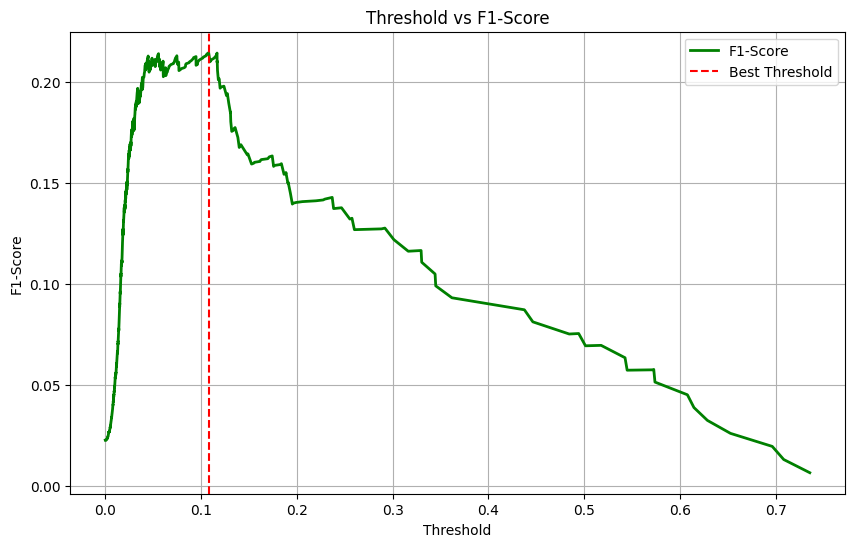

In [6]:
# 1. 1(팔림)이 될 '확률(Probability)'만 따로 추출
proba = final_model.predict_proba(X_test)[:, 1]

# 2. 다양한 임계값(Threshold) 테스트
thresholds = np.arange(0.05, 0.95, 0.05)
best_f1 = 0
best_thresh = 0.5

print('Threshold | Precision | Recall | F1-Score')
print('-' * 45)
for thresh in thresholds:
    # 확률이 thresh 이상일 때만 1로 예측
    custom_preds = (proba >= thresh).astype(int)

    p = precision_score(y_test, custom_preds, zero_division=0)
    r = recall_score(y_test, custom_preds)
    f1 = f1_score(y_test, custom_preds)

    print(f'{thresh:.2f}      | {p:.4f}    | {r:.4f} | {f1:.4f}')

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f'\n최적의 Threshold: {best_thresh:.2f} (최고 F1-score: {best_f1:.4f})')


def find_optimal_threshold(y_true, y_proba):
    # 1. 가능한 모든 임계값과 그에 따른 정밀도, 재현율 계산
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)

    # 2. 각 임계값에서의 F1-score 계산 (분모가 0이 되는 것을 방지하기 위해 1e-10 추가)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

    # 3. F1-score가 가장 높은 지점의 인덱스 추출
    best_idx = np.argmax(f1_scores)

    # 4. 최적의 임계값과 그때의 F1-score
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print('🌟 [최적 임계값 탐색 결과] 🌟')
    print(f'👉 Best Threshold : {best_threshold:.4f}')
    print(f'👉 Best F1-Score  : {best_f1:.4f}\n')

    return best_threshold


def plot_threshold_curve(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

    plt.figure(figsize=(10, 6))
    # thresholds는 precisions/recalls보다 길이가 1 짧으므로 슬라이싱 필요
    plt.plot(thresholds, f1_scores[:-1], label='F1-Score', color='green', linewidth=2)
    plt.axvline(
        x=thresholds[np.argmax(f1_scores)],
        color='red',
        linestyle='--',
        label='Best Threshold',
    )

    plt.title('Threshold vs F1-Score')
    plt.xlabel('Threshold')
    plt.ylabel('F1-Score')
    plt.legend()
    plt.grid(True)
    plt.show()


# 최적 임계값 구하기 (y_test는 테스트 데이터의 실제 정답)
y_proba = final_model.predict_proba(X_test)[:, 1]
best_threshold = find_optimal_threshold(y_test, y_proba)

# 확률값이 best_threshold 이상이면 1.0, 아니면 0.0으로 변환
y_pred_custom = (y_proba >= best_threshold).astype(float)

# 최종 성능 확인
print('✅ [최적 임계값 적용 후 Classification Report]')
print(classification_report(y_test, y_pred_custom))

# 그래프 그리기
plot_threshold_curve(y_test, y_proba)

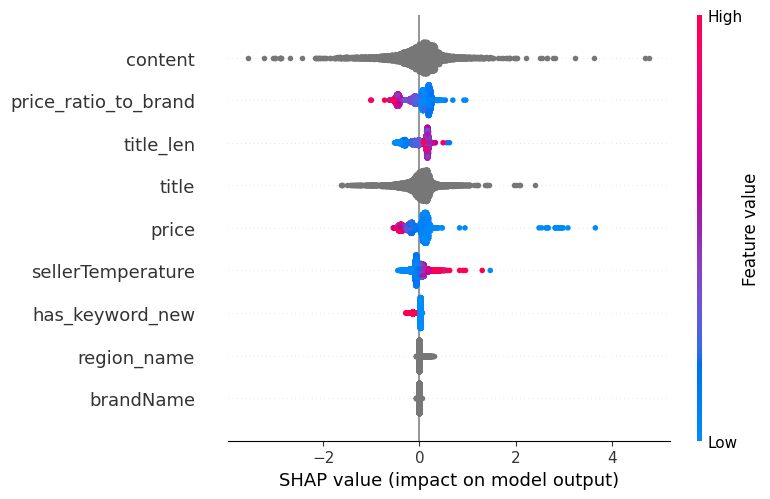

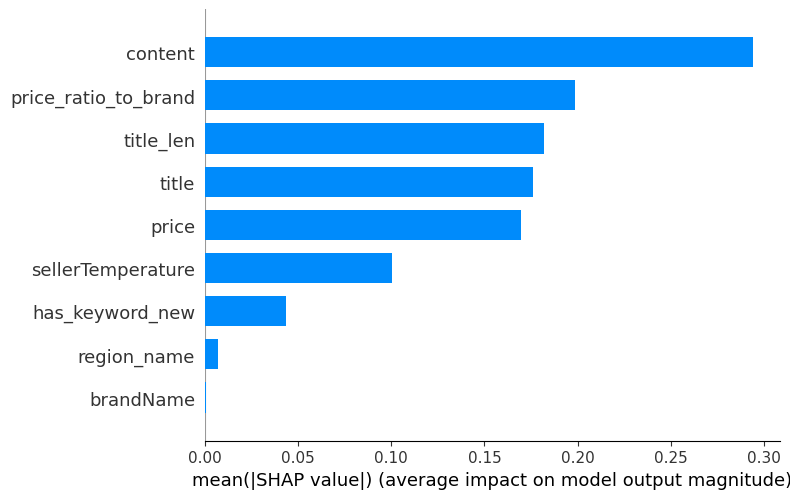

In [8]:
X_test_sample = X_test.sample(n=10000, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

sample_pool = catboost.Pool(
    data=X_test_sample, cat_features=cat_features, text_features=text_features
)

# 1. 트리 모델용 초고속 SHAP Explainer 선언
explainer = shap.TreeExplainer(final_model)

# 2. Test Set 일부에 대한 SHAP 값 계산 (속도가 빨라 더 많이 넣어도 됩니다)
X_test_sample = X_test.sample(n=10000, random_state=42)
# shap_values = explainer(X_test_sample)
shap_values = explainer.shap_values(sample_pool)

# 3. 전체 Feature Importance 시각화 (요약 플롯)
# 피처가 예측값(판매 확률)을 높이는 데 기여했는지 낮추는 데 기여했는지 색상으로 보여줍니다.
shap.summary_plot(shap_values, X_test_sample)

# 4. 단순 막대 그래프로 중요도 순위만 보고 싶을 때
shap.summary_plot(shap_values, X_test_sample, plot_type='bar')

판매 아이템: 슈슈앤크라 에뜨와 여아 점퍼 24개월 일괄판매
본문 내용: 슈슈앤크라 
핑크 메쉬 가디건 (한여름 에어컨용이에요)
화이트 반팔 블라우스
핑크 바람막이

에뜨와 화이트 점퍼

총 4벌 일괄판매합니다. 
컨디션 좋고 오염없이 깨끗합니다. 
슈...
실제 7일 내 판매 여부: ✅ 팔림
🔥 AI 예측 판매 확률: 73.55%



c:\potenup3\pj02_daangn-marke\.venv\Lib\site-packages\shap\plots\_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
c:\potenup3\pj02_daangn-marke\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


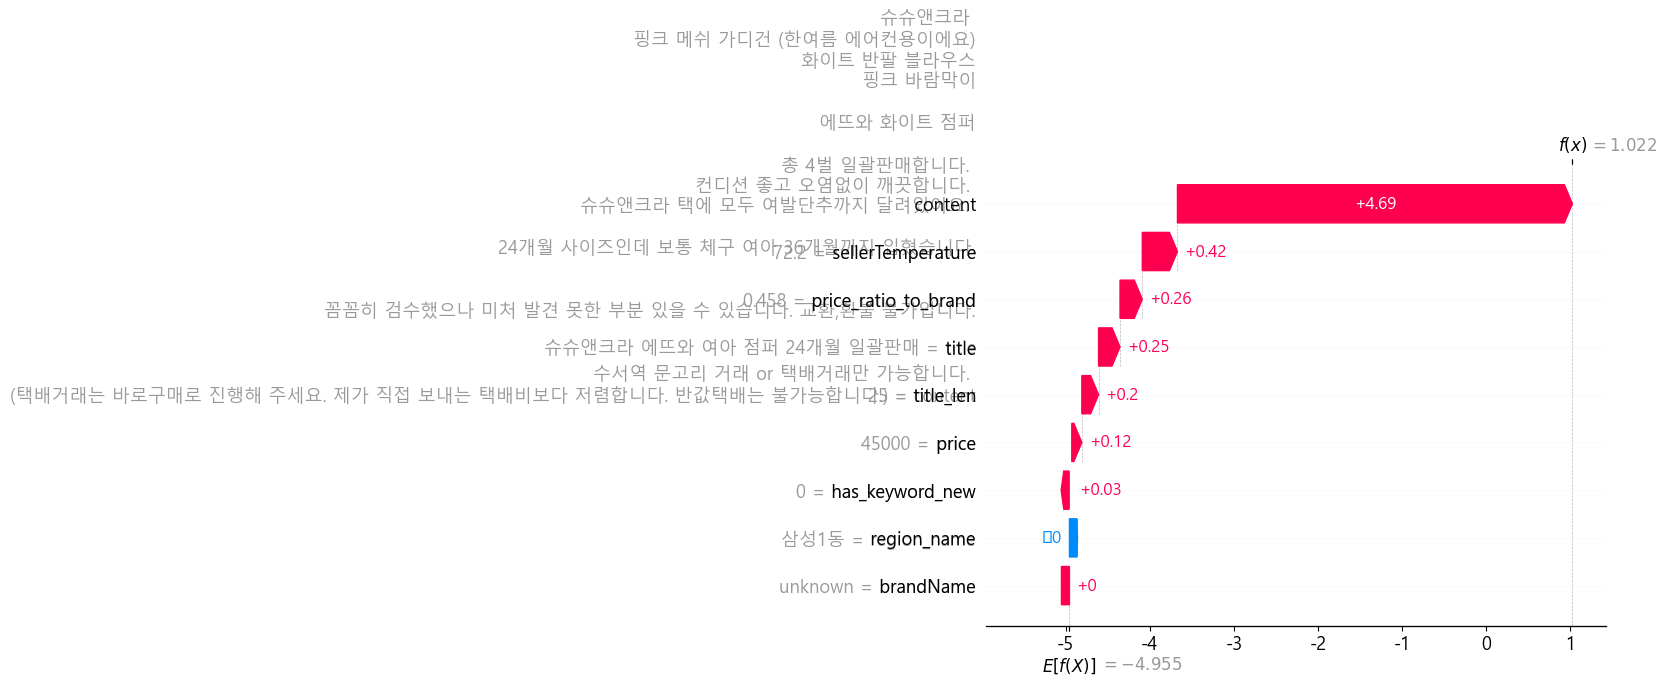

In [9]:
# (한글 폰트 깨짐 방지 설정 - 윈도우 맑은고딕 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. SHAP TreeExplainer 선언
explainer = shap.TreeExplainer(final_model)

# 2. 분석하고 싶은 데이터 딱 1개 고르기
best_idx = np.argmax(final_model.predict_proba(X_test)[:, 1])
sample_data = X_test.iloc[[best_idx]]
sample_target = y_test.iloc[best_idx]
sample_proba = final_model.predict_proba(sample_data)[0, 1]

# 3. 텍스트 피처 에러 방지를 위한 Pool 객체로 감싸기
sample_pool = catboost.Pool(
    sample_data, cat_features=cat_features, text_features=text_features
)

# 4. SHAP 값 계산
shap_values = explainer(sample_pool)

# ★ 에러 해결의 핵심: SHAP 객체 내부의 'Pool' 데이터를 실제 텍스트/숫자 데이터로 교체 ★
shap_values.data = sample_data.values
shap_values.feature_names = sample_data.columns.tolist()

# 5. 결과 출력 및 Waterfall 차트 시각화
print('==========================================')
print(f'판매 아이템: {sample_data["title"].values[0]}')
print(f'본문 내용: {sample_data["content"].values[0][:100]}...')
print(f'실제 7일 내 판매 여부: {"✅ 팔림" if sample_target == 1 else "❌ 안 팔림"}')
print(f'🔥 AI 예측 판매 확률: {sample_proba * 100:.2f}%')
print('==========================================\n')

# 폭포수(Waterfall) 차트 그리기
shap.plots.waterfall(shap_values[0], max_display=10)  # 상위 10개 피처만 깔끔하게 보기

In [30]:
# 2. '가성비' 계산을 위한 평균 가격 정보 딕셔너리화 (매우 중요!)
# 실제 서비스에서는 이 딕셔너리들을 pickle 파일이나 DB에 저장해두고 불러와서 씁니다.
brand_mean_dict = df.groupby('brandName')['price'].mean().to_dict()


# ---------------------------------------------------------
# [2] 새로운 게시글 예측 함수 만들기
# ---------------------------------------------------------
def predict_sell_probability(
    title,
    content,
    price,
    brandName,
    region_name,
    seller_temp=36.5,
):
    """
    새로운 게시글 정보를 입력받아 n일 이내 판매 확률을 반환하는 함수
    """
    # 1. 모델 불러오기 (실제 환경에서는 서버가 켜질 때 한 번만 불러옵니다)
    loaded_model = CatBoostClassifier()
    loaded_model.load_model('../data/models/daangn_sell_predictor_PR.cbm')

    # 2. 파생 변수(가성비) 계산
    # 딕셔너리에 없는 새로운 브랜드/라벨이 들어오면 내 가격을 평균으로 간주 (비율이 1이 되도록)
    b_mean = brand_mean_dict.get(brandName, price)

    price_ratio_to_brand = price / (b_mean + 1)

    title_len = len(str(title))
    has_keyword_new = (
        1 if re.search(r'새상품|미개봉|새제품|택포|급처', str(title)) else 0
    )

    # 3. 모델에 넣을 데이터프레임 구성 (학습 때 사용한 features 리스트와 정확히 동일해야 함!)
    # --- 모델 입력용 데이터프레임 조립 ---
    input_data = pd.DataFrame(
        [
            {
                'price': price,
                'price_ratio_to_brand': price_ratio_to_brand,
                'sellerTemperature': seller_temp,
                'title_len': title_len,
                'has_keyword_new': has_keyword_new,
                'title': title,
                'content': content,
                'region_name': region_name,
                'brandName': brandName,
            }
        ]
    )

    # 결측치 처리 (학습 때와 동일하게)
    input_data['region_name'] = input_data['region_name'].fillna('unknown')

    # 4. 예측 수행
    proba = loaded_model.predict_proba(input_data)[0, 1]

    print('==========================================')
    print(f'판매 아이템: {title}')
    print(f'희망 가격: {price:,}원 (브랜드 평균 대비 {price_ratio_to_brand:.2f}배)')
    print(f'🔥 AI 예측 판매 확률: {proba * 100:.2f}%')
    print('==========================================\n')

    return proba


# ---------------------------------------------------------
# [3] 가상 데이터로 즉석 테스트 해보기
# ---------------------------------------------------------
# 가상 데이터 1: 매력적인 조건의 글
predict_sell_probability(
    title='유아의류 일괄 밍크뮤 블루독 3세 (90)사이즈 외',
    content='1. 밍크뮤 3세사이즈\n2. 밍크뮤 12개월 사이즈\n3. 위쪽 두개 블루독 100사이즈\n아래쪽 아디다스 90사이즈\n4. 5. 내복 에뜨와, 밍크뮤 2y',
    price=35_000,
    brandName='nike',
    region_name='역삼동',
    seller_temp=40.2,
)

# 가상 데이터 2: 안 팔릴 것 같은 글
predict_sell_probability(
    title='나이키 패딩',
    content='입을만 합니다 네고 불가',
    price=150_000,
    brandName='nike',
    region_name='역삼동',
    seller_temp=36.5,
)

판매 아이템: 유아의류 일괄 밍크뮤 블루독 3세 (90)사이즈 외
희망 가격: 35,000원 (브랜드 평균 대비 0.75배)
🔥 AI 예측 판매 확률: 0.59%

판매 아이템: 나이키 패딩
희망 가격: 150,000원 (브랜드 평균 대비 3.23배)
🔥 AI 예측 판매 확률: 0.27%



np.float64(0.0027300553061933752)

## 2. Buyer-side Model

In [20]:
buy_features = [
    # --- 판매자 관점에서 볼 수 있는 현재 반응도 데이터 ---
    'price',
    'price_log',
    'price_ratio_to_brand',
    'sellerTemperature',
    'title_len',
    'has_keyword_new',
    'title',
    'content',
    'region_name',
    'brandName',
    # --- 구매자 관점에서 볼 수 있는 현재 반응도 데이터 ---
    'viewCount',
    'favoriteCount',
    'chatCount',
    'favorite_per_view',
    'chat_per_view',
    'is_boosted',
]

X_train = df[buy_features]
y_train = df['target_n_days']

cat_features = ['region_name', 'brandName']
text_features = ['title', 'content']

# ---------------------------------------------------------
# [2] Train / Test 분할 및 Pool 생성
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

train_pool = Pool(
    X_train, y_train, cat_features=cat_features, text_features=text_features
)
valid_pool = Pool(
    X_test, y_test, cat_features=cat_features, text_features=text_features
)

In [49]:
# ==========================================
# 2. Optuna Objective 함수 정의
# ==========================================
def objective(trial):
    # 탐색할 하이퍼파라미터 공간 정의
    param = {
        'iterations': trial.suggest_int('iterations', 500, 1500),  # 학습 횟수
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int(
            'depth', 4, 10
        ),  # 텍스트 모델은 메모리를 많이 쓰므로 최대 8 권장
        'l2_leaf_reg': trial.suggest_float(
            'l2_leaf_reg', 1e-3, 10.0, log=True
        ),  # 정규화
        'random_strength': trial.suggest_float(
            'random_strength', 1e-3, 10.0, log=True
        ),  # 과적합 방지
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'bootstrap_type': 'Bayesian',  # 🌟 수정됨: GPU 환경에서 bagging_temperature 쓸 때 필수
        # 고정 파라미터
        'eval_metric': 'Logloss',
        'random_seed': 42,
        'task_type': 'GPU',
        'verbose': 0,  # 튜닝 중에는 로그 출력 끄기
    }

    model = CatBoostClassifier(**param)

    # 모델 학습 (Early Stopping 적용)
    model.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=50)

    # 검증셋에서 가장 높았던 PR-AUC 점수를 반환
    proba = model.predict_proba(X_test)[:, 1]
    pr_auc = average_precision_score(y_test, proba)

    return pr_auc


# ==========================================
# 3. Optuna Study 실행 (탐색 시작)
# ==========================================
print('🚀 Optuna 하이퍼파라미터 탐색을 시작합니다...')
study = optuna.create_study(direction='maximize')  # PR-AUC는 높을수록 좋으므로 maximize
study.optimize(
    objective, n_trials=100
)  # 우선 30번만 시도 (시간에 따라 50~100번으로 늘려보세요)

print('\n🏆 [Best Trial]')
print(f'최고 PR-AUC 점수: {study.best_value:.4f}')
print('최적의 파라미터:')
for key, value in study.best_params.items():
    print(f'  {key}: {value}')

# ==========================================
# 4. 찾은 최적 파라미터로 최종 모델 학습 및 평가
# ==========================================
print('\n🔥 찾은 최적의 파라미터로 최종 모델을 학습합니다...')
best_params = study.best_params

# 고정 파라미터 다시 추가
best_params.update(
    {
        'eval_metric': 'Logloss',
        'random_seed': 42,
        'task_type': 'GPU',
        'verbose': 50,  # 최종 학습이므로 로그 출력
    }
)

final_model = CatBoostClassifier(**best_params)
final_model.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=50)

# 최종 평가
preds = final_model.predict(X_test)
proba = final_model.predict_proba(X_test)[:, 1]

average_precision = average_precision_score(y_test, proba)
print('\n✅ [최종 모델 평가 지표]')
print(classification_report(y_test, preds))
print(f'PR-AUC: {average_precision:.4f}')

# ==========================================
# 5. Permutation Importance 계산 (최종 1회)
# ==========================================
print('\n📊 Permutation Importance 계산 중... (시간이 조금 소요됩니다)')
X_test_sample = X_test.sample(n=10000, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

# 텍스트 피처가 있으므로 Pool 형태로 묶어서 에러 방지 (필요 시)
sample_pool = Pool(
    X_test_sample, y_test_sample, cat_features=cat_features, text_features=text_features
)

result = permutation_importance(
    final_model,
    X_test_sample,  # Pool이 아닌 DataFrame 자체를 넣어야 사이킷런과 호환됨
    y_test_sample,
    n_repeats=6,
    random_state=42,
    scoring='average_precision',
    n_jobs=-1,
)

perm_imp_df = pd.DataFrame(
    {
        'Feature': X_test_sample.columns,
        'Importance': result.importances_mean,
        'Std': result.importances_std,
    }
).sort_values(by='Importance', ascending=False)

print('\n[Permutation Importance 결과]')
print(perm_imp_df)

# 최종 모델 저장 (선택)
final_model.save_model('../data/models/daangn_buy_predictor_PR.cbm')

[I 2026-03-10 05:17:35,284] A new study created in memory with name: no-name-afc5b716-059f-4f36-8b27-e3ba01c44356


🚀 Optuna 하이퍼파라미터 탐색을 시작합니다...


[I 2026-03-10 05:17:46,984] Trial 0 finished with value: 0.428596274280067 and parameters: {'iterations': 776, 'learning_rate': 0.060320530374986095, 'depth': 4, 'l2_leaf_reg': 0.33423393651727096, 'random_strength': 4.43952777740511, 'bagging_temperature': 0.47840251442376114}. Best is trial 0 with value: 0.428596274280067.
[I 2026-03-10 05:18:25,540] Trial 1 finished with value: 0.4530182989931368 and parameters: {'iterations': 1342, 'learning_rate': 0.012107224456162717, 'depth': 9, 'l2_leaf_reg': 0.013081363392487867, 'random_strength': 1.213034218387299, 'bagging_temperature': 0.2746767626462757}. Best is trial 1 with value: 0.4530182989931368.
[I 2026-03-10 05:18:38,810] Trial 2 finished with value: 0.40808414976207147 and parameters: {'iterations': 775, 'learning_rate': 0.013496004592470624, 'depth': 5, 'l2_leaf_reg': 0.002633264616695664, 'random_strength': 0.1163639255840586, 'bagging_temperature': 0.2751877321457288}. Best is trial 1 with value: 0.4530182989931368.
[I 2026-03


🏆 [Best Trial]
최고 PR-AUC 점수: 0.4579
최적의 파라미터:
  iterations: 1469
  learning_rate: 0.039211060978992004
  depth: 10
  l2_leaf_reg: 3.2228874688301996
  random_strength: 0.07495456011760979
  bagging_temperature: 0.9032624860066143

🔥 찾은 최적의 파라미터로 최종 모델을 학습합니다...
0:	learn: 0.5666645	test: 0.5668884	best: 0.5668884 (0)	total: 154ms	remaining: 3m 45s
50:	learn: 0.0327084	test: 0.0355819	best: 0.0355819 (50)	total: 2.72s	remaining: 1m 15s
100:	learn: 0.0300502	test: 0.0341765	best: 0.0341765 (100)	total: 5.02s	remaining: 1m 8s
150:	learn: 0.0289485	test: 0.0338345	best: 0.0338345 (150)	total: 7.28s	remaining: 1m 3s
200:	learn: 0.0278628	test: 0.0336041	best: 0.0335984 (198)	total: 9.54s	remaining: 1m
250:	learn: 0.0270232	test: 0.0335036	best: 0.0335029 (249)	total: 11.8s	remaining: 57.2s
300:	learn: 0.0261991	test: 0.0333104	best: 0.0333104 (300)	total: 14s	remaining: 54.5s
350:	learn: 0.0254806	test: 0.0331764	best: 0.0331764 (350)	total: 16.3s	remaining: 51.9s
400:	learn: 0.0247569	test

In [17]:
final_model = CatBoostClassifier()
final_model.load_model('../data/models/daangn_buy_predictor_PR.cbm')

CatBoostClassifier(bagging_temperature=0.903262486, depth=10, eval_metric='Logloss', iterations=1469, l2_leaf_reg=3.222887469, learning_rate=0.03921106098, loss_function='Logloss', od_type='Iter', od_wait=50, random_seed=42, random_strength=0.07495456012, task_type='GPU', verbose=50)

Threshold | Precision | Recall | F1-Score
---------------------------------------------
0.05      | 0.2242    | 0.8020 | 0.3504
0.10      | 0.2817    | 0.6964 | 0.4011
0.15      | 0.3533    | 0.6436 | 0.4561
0.20      | 0.4308    | 0.5545 | 0.4848
0.25      | 0.5128    | 0.4620 | 0.4861
0.30      | 0.5556    | 0.3795 | 0.4510
0.35      | 0.6027    | 0.2904 | 0.3920
0.40      | 0.6306    | 0.2310 | 0.3382
0.45      | 0.6628    | 0.1881 | 0.2931
0.50      | 0.7273    | 0.1584 | 0.2602
0.55      | 0.7755    | 0.1254 | 0.2159
0.60      | 0.8293    | 0.1122 | 0.1977
0.65      | 0.8788    | 0.0957 | 0.1726
0.70      | 0.8400    | 0.0693 | 0.1280
0.75      | 0.8235    | 0.0462 | 0.0875
0.80      | 0.8333    | 0.0330 | 0.0635
0.85      | 1.0000    | 0.0198 | 0.0388
0.90      | 1.0000    | 0.0033 | 0.0066

최적의 Threshold: 0.25 (최고 F1-score: 0.4861)
🌟 [최적 임계값 탐색 결과] 🌟
👉 Best Threshold : 0.2046
👉 Best F1-Score  : 0.4934

✅ [최적 임계값 적용 후 Classification Report]
              precision    recall  f1-s

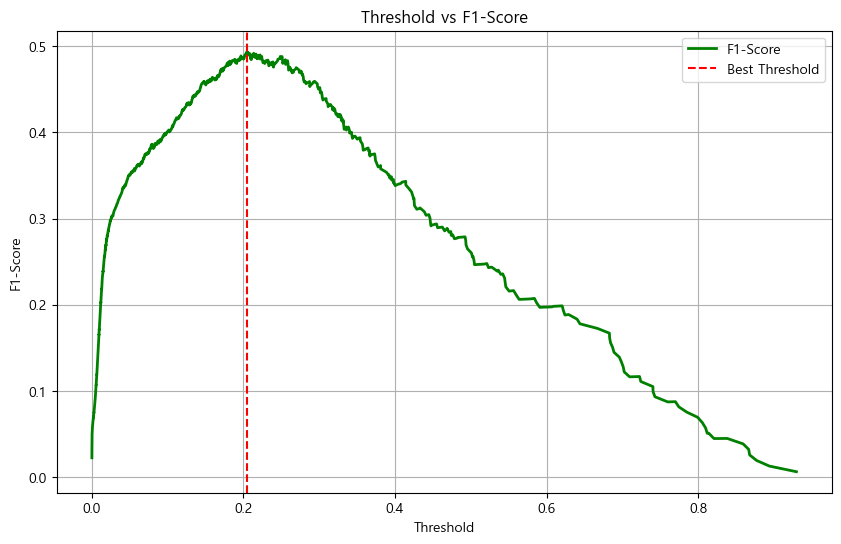

In [18]:
# 1. 1(팔림)이 될 '확률(Probability)'만 따로 추출
proba = final_model.predict_proba(X_test)[:, 1]

# 2. 다양한 임계값(Threshold) 테스트
thresholds = np.arange(0.05, 0.95, 0.05)
best_f1 = 0
best_thresh = 0.5

print('Threshold | Precision | Recall | F1-Score')
print('-' * 45)
for thresh in thresholds:
    # 확률이 thresh 이상일 때만 1로 예측
    custom_preds = (proba >= thresh).astype(int)

    p = precision_score(y_test, custom_preds, zero_division=0)
    r = recall_score(y_test, custom_preds)
    f1 = f1_score(y_test, custom_preds)

    print(f'{thresh:.2f}      | {p:.4f}    | {r:.4f} | {f1:.4f}')

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f'\n최적의 Threshold: {best_thresh:.2f} (최고 F1-score: {best_f1:.4f})')


def find_optimal_threshold(y_true, y_proba):
    # 1. 가능한 모든 임계값과 그에 따른 정밀도, 재현율 계산
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)

    # 2. 각 임계값에서의 F1-score 계산 (분모가 0이 되는 것을 방지하기 위해 1e-10 추가)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

    # 3. F1-score가 가장 높은 지점의 인덱스 추출
    best_idx = np.argmax(f1_scores)

    # 4. 최적의 임계값과 그때의 F1-score
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print('🌟 [최적 임계값 탐색 결과] 🌟')
    print(f'👉 Best Threshold : {best_threshold:.4f}')
    print(f'👉 Best F1-Score  : {best_f1:.4f}\n')

    return best_threshold


def plot_threshold_curve(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

    plt.figure(figsize=(10, 6))
    # thresholds는 precisions/recalls보다 길이가 1 짧으므로 슬라이싱 필요
    plt.plot(thresholds, f1_scores[:-1], label='F1-Score', color='green', linewidth=2)
    plt.axvline(
        x=thresholds[np.argmax(f1_scores)],
        color='red',
        linestyle='--',
        label='Best Threshold',
    )

    plt.title('Threshold vs F1-Score')
    plt.xlabel('Threshold')
    plt.ylabel('F1-Score')
    plt.legend()
    plt.grid(True)
    plt.show()


# 최적 임계값 구하기 (y_test는 테스트 데이터의 실제 정답)
y_proba = final_model.predict_proba(X_test)[:, 1]
best_threshold = find_optimal_threshold(y_test, y_proba)

# 확률값이 best_threshold 이상이면 1.0, 아니면 0.0으로 변환
y_pred_custom = (y_proba >= best_threshold).astype(float)

# 최종 성능 확인
print('✅ [최적 임계값 적용 후 Classification Report]')
print(classification_report(y_test, y_pred_custom))

# 그래프 그리기
plot_threshold_curve(y_test, y_proba)

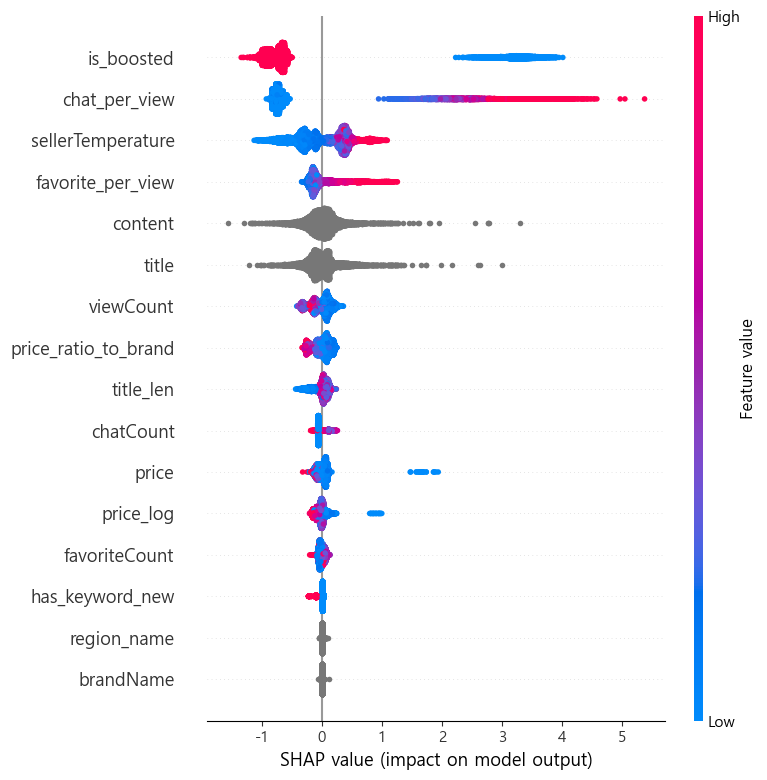

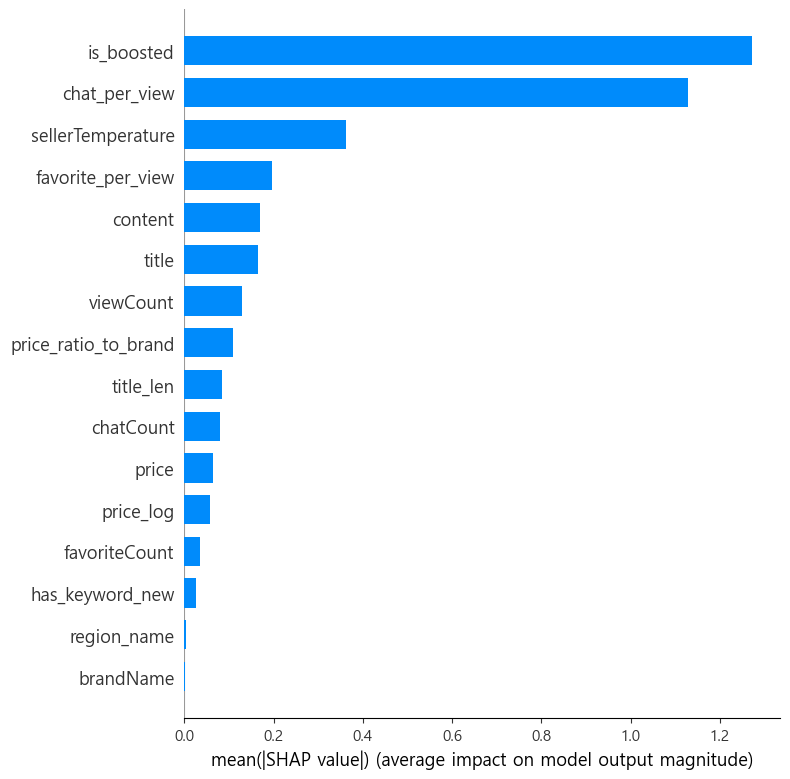

In [21]:
X_test_sample = X_test.sample(n=10000, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

sample_pool = catboost.Pool(
    data=X_test_sample, cat_features=cat_features, text_features=text_features
)

# 1. 트리 모델용 초고속 SHAP Explainer 선언
explainer = shap.TreeExplainer(final_model)

# 2. Test Set 일부에 대한 SHAP 값 계산 (속도가 빨라 더 많이 넣어도 됩니다)
X_test_sample = X_test.sample(n=10000, random_state=42)
# shap_values = explainer(X_test_sample)
shap_values = explainer.shap_values(sample_pool)

# 3. 전체 Feature Importance 시각화 (요약 플롯)
# 피처가 예측값(판매 확률)을 높이는 데 기여했는지 낮추는 데 기여했는지 색상으로 보여줍니다.
shap.summary_plot(shap_values, X_test_sample)

# 4. 단순 막대 그래프로 중요도 순위만 보고 싶을 때
shap.summary_plot(shap_values, X_test_sample, plot_type='bar')

판매 아이템: 슈슈앤크라 에뜨와 여아 점퍼 24개월 일괄판매
본문 내용: 슈슈앤크라 
핑크 메쉬 가디건 (한여름 에어컨용이에요)
화이트 반팔 블라우스
핑크 바람막이

에뜨와 화이트 점퍼

총 4벌 일괄판매합니다. 
컨디션 좋고 오염없이 깨끗합니다. 
슈...
실제 7일 내 판매 여부: ✅ 팔림
🔥 AI 예측 판매 확률: 92.98%



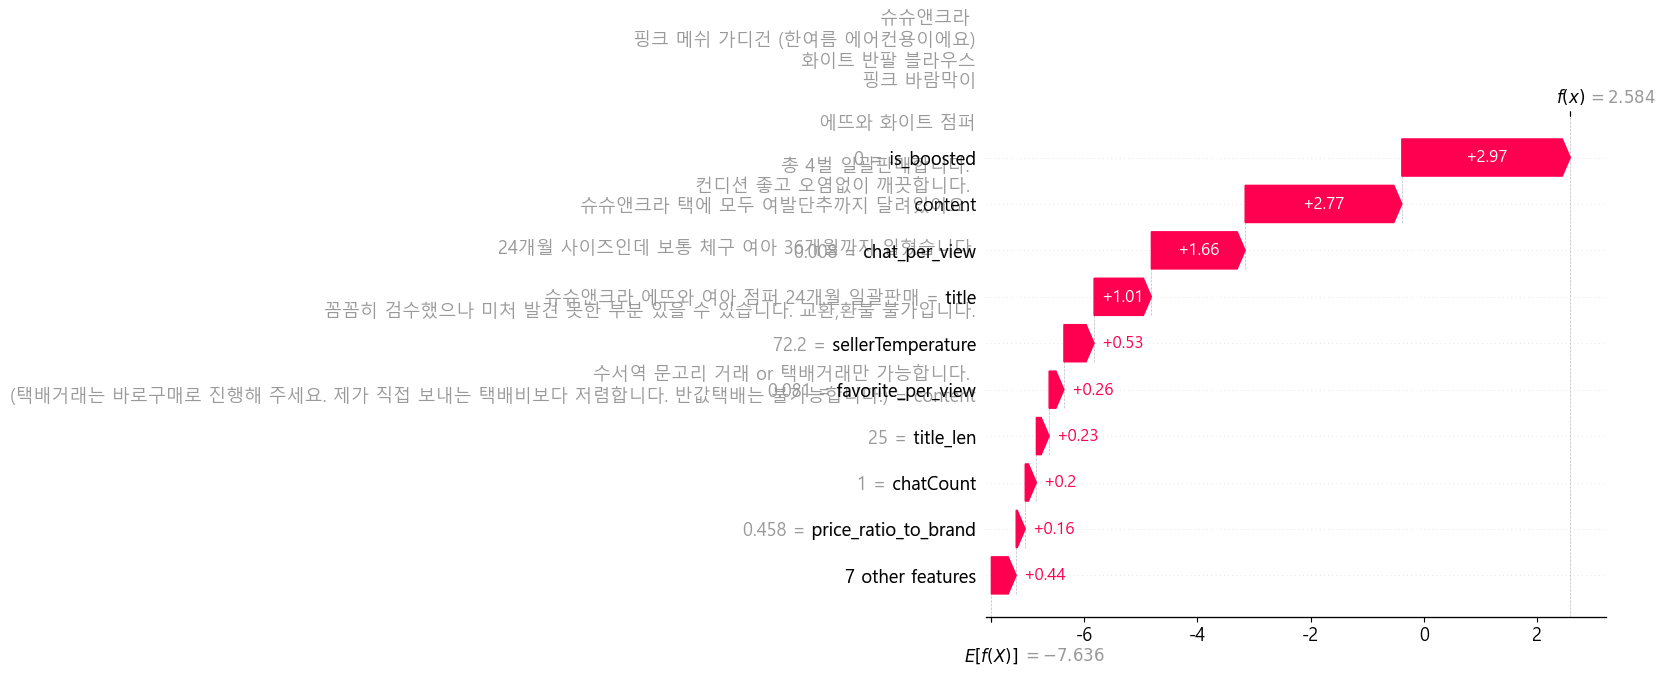

In [22]:
# (한글 폰트 깨짐 방지 설정 - 윈도우 맑은고딕 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. SHAP TreeExplainer 선언
explainer = shap.TreeExplainer(final_model)

# 2. 분석하고 싶은 데이터 딱 1개 고르기
best_idx = np.argmax(final_model.predict_proba(X_test)[:, 1])
sample_data = X_test.iloc[[best_idx]]
sample_target = y_test.iloc[best_idx]
sample_proba = final_model.predict_proba(sample_data)[0, 1]

# 3. 텍스트 피처 에러 방지를 위한 Pool 객체로 감싸기
sample_pool = catboost.Pool(
    sample_data, cat_features=cat_features, text_features=text_features
)

# 4. SHAP 값 계산
shap_values = explainer(sample_pool)

# ★ 에러 해결의 핵심: SHAP 객체 내부의 'Pool' 데이터를 실제 텍스트/숫자 데이터로 교체 ★
shap_values.data = sample_data.values
shap_values.feature_names = sample_data.columns.tolist()

# 5. 결과 출력 및 Waterfall 차트 시각화
print('==========================================')
print(f'판매 아이템: {sample_data["title"].values[0]}')
print(f'본문 내용: {sample_data["content"].values[0][:100]}...')
print(f'실제 7일 내 판매 여부: {"✅ 팔림" if sample_target == 1 else "❌ 안 팔림"}')
print(f'🔥 AI 예측 판매 확률: {sample_proba * 100:.2f}%')
print('==========================================\n')

# 폭포수(Waterfall) 차트 그리기
shap.plots.waterfall(shap_values[0], max_display=10)  # 상위 10개 피처만 깔끔하게 보기

In [23]:
# 2. '가성비' 계산을 위한 평균 가격 정보 딕셔너리화 (매우 중요!)
# 실제 서비스에서는 이 딕셔너리들을 pickle 파일이나 DB에 저장해두고 불러와서 씁니다.
brand_mean_dict = df.groupby('brandName')['price'].mean().to_dict()


# ---------------------------------------------------------
# [2] 새로운 게시글 예측 함수 만들기
# ---------------------------------------------------------
def predict_sell_probability(
    title,
    content,
    price,
    brandName,
    region_name,
    viewCount,
    favoriteCount,
    chatCount,
    is_boosted,
    seller_temp=36.5,
):
    """
    새로운 게시글 정보를 입력받아 n일 이내 판매 확률을 반환하는 함수
    """
    # 1. 모델 불러오기 (실제 환경에서는 서버가 켜질 때 한 번만 불러옵니다)
    loaded_model = CatBoostClassifier()
    loaded_model.load_model('../data/models/daangn_buy_predictor_PR.cbm')

    # 2. 파생 변수(가성비) 계산
    # 딕셔너리에 없는 새로운 브랜드/라벨이 들어오면 내 가격을 평균으로 간주 (비율이 1이 되도록)
    b_mean = brand_mean_dict.get(brandName, price)

    price_ratio_to_brand = price / (b_mean + 1)

    title_len = len(str(title))
    has_keyword_new = (
        1 if re.search(r'새상품|미개봉|새제품|택포|급처', str(title)) else 0
    )

    # 3. 모델에 넣을 데이터프레임 구성 (학습 때 사용한 features 리스트와 정확히 동일해야 함!)
    # --- 모델 입력용 데이터프레임 조립 ---
    input_data = pd.DataFrame(
        [
            {
                'price': price,
                'price_log': np.log1p(price),
                'price_ratio_to_brand': price_ratio_to_brand,
                'sellerTemperature': seller_temp,
                'title_len': title_len,
                'has_keyword_new': has_keyword_new,
                'title': title,
                'content': content,
                'region_name': region_name,
                'brandName': brandName,
                'viewCount': viewCount,
                'favoriteCount': favoriteCount,
                'chatCount': chatCount,
                'favorite_per_view': favoriteCount / (viewCount + 1),
                'chat_per_view': chatCount / (viewCount + 1),
                'is_boosted': is_boosted,
            }
        ]
    )

    # 결측치 처리 (학습 때와 동일하게)
    input_data['region_name'] = input_data['region_name'].fillna('unknown')

    # 4. 예측 수행
    proba = loaded_model.predict_proba(input_data)[0, 1]

    print('==========================================')
    print(f'판매 아이템: {title}')
    print(f'희망 가격: {price:,}원 (브랜드 평균 대비 {price_ratio_to_brand:.2f}배)')
    print(f'🔥 AI 예측 판매 확률: {proba * 100:.2f}%')
    print('==========================================\n')

    return proba


# ---------------------------------------------------------
# [3] 가상 데이터로 즉석 테스트 해보기
# ---------------------------------------------------------
# 가상 데이터 1: 매력적인 조건의 글
predict_sell_probability(
    title='나이키 숏패딩 블랙 M 급처합니다',
    content='선물 받았는데 사이즈가 안 맞아서 팝니다. 택 안 뗀 새상품이에요. 쿨거래 시 택포해드림.',
    price=25_000,
    brandName='nike',
    region_name='역삼동',
    viewCount=100,
    favoriteCount=20,
    chatCount=6,
    is_boosted=0,
    seller_temp=45.2,
)

# 가상 데이터 2: 안 팔릴 것 같은 글
predict_sell_probability(
    title='나이키 패딩',
    content='입을만 합니다 네고 불가',
    price=150_000,
    brandName='nike',
    region_name='역삼동',
    viewCount=79,
    favoriteCount=5,
    chatCount=1,
    is_boosted=0,
    seller_temp=36.5,
)

판매 아이템: 나이키 숏패딩 블랙 M 급처합니다
희망 가격: 25,000원 (브랜드 평균 대비 0.54배)
🔥 AI 예측 판매 확률: 55.87%

판매 아이템: 나이키 패딩
희망 가격: 150,000원 (브랜드 평균 대비 3.23배)
🔥 AI 예측 판매 확률: 4.24%



np.float64(0.042428706968032116)

In [25]:
# 1. 전체 Test 데이터에 예측 확률과 실제 정답 붙이기
analysis_df = X_test.copy()
analysis_df['actual_target'] = y_test
analysis_df['pred_proba'] = final_model.predict_proba(X_test)[:, 1]

# ---------------------------------------------------------
# [유형 1] False Positive (FP): 모델은 무조건 팔린다고(85% 이상) 했는데, 안 팔린 상품
# ---------------------------------------------------------
false_positives = analysis_df[
    (analysis_df['actual_target'] == 0) & (analysis_df['pred_proba'] >= 0.85)
].sort_values(by='pred_proba', ascending=False)

print(
    f'🚨 [False Positives] 모델은 팔린다고 확신했지만 안 팔린 게시글: {len(false_positives)}개'
)

# 상위 5개 뽑아보기
for idx, row in false_positives.head(5).iterrows():
    # ★ 수정된 부분: X_test에 없는 브랜드명은 원본 train_df에서 인덱스(idx)로 가져옵니다.
    original_brand = train_df.loc[idx, 'brandName']

    print(
        f'확률: {row["pred_proba"]:.2f} | 가격: {row["price"]:,.0f}원 | 브랜드: {original_brand}'
    )
    print(f'제목: {row["title"]}')
    print(f'본문: {row["content"][:100]}...')  # 본문은 100자까지만
    print('-' * 50)


print('\n\n')


# ---------------------------------------------------------
# [유형 2] False Negative (FN): 모델은 절대 안 팔린다고(10% 이하) 했는데, 팔린 상품
# ---------------------------------------------------------
false_negatives = analysis_df[
    (analysis_df['actual_target'] == 1) & (analysis_df['pred_proba'] <= 0.10)
].sort_values(by='pred_proba', ascending=True)

print(
    f'🚨 [False Negatives] 모델은 안 팔린다고 확신했지만 실제론 팔린 게시글: {len(false_negatives)}개'
)

# 하위 5개 뽑아보기
for idx, row in false_negatives.head(5).iterrows():
    # ★ 수정된 부분
    original_brand = df.loc[idx, 'brandName']

    print(
        f'확률: {row["pred_proba"]:.2f} | 가격: {row["price"]:,.0f}원 | 브랜드: {original_brand}'
    )
    print(f'제목: {row["title"]}')
    print(f'본문: {row["content"][:100]}...')
    print('-' * 50)

🚨 [False Positives] 모델은 팔린다고 확신했지만 안 팔린 게시글: 0개



🚨 [False Negatives] 모델은 안 팔린다고 확신했지만 실제론 팔린 게시글: 92개
확률: 0.00 | 가격: 23,000원 | 브랜드: uniqlo
제목: 유니클로U 데님 팬츠 size 32
본문: 크리스토퍼 르메르가 디렉팅하는 유니클로 U 라인의 데님 팬츠.
시원한 아이스블루 색상으로 다가오는 봄부터 입기 좋은 디자인입니다.
허리 32 사이즈이며사용감 없는 좋은 컨디션 유지...
--------------------------------------------------
확률: 0.00 | 가격: 7,000원 | 브랜드: unknown
제목: 여성용 체크 셔츠 free 사이즈입니다
본문: 여성용 체크 셔츠 free 사이즈입니다 😊
루즈핏으로 여리여리하게 입기 좋아요.
네이비 바탕에 카키/옐로우 체크 컬러라
데님, 슬랙스 어디에나 잘 어울려요.
✔️ 오버핏 스타일
✔...
--------------------------------------------------
확률: 0.00 | 가격: 38,000원 | 브랜드: titleist
제목: 타이틀리스트 간절기 긴팔 (95)
본문: *구매전 안내 사항 ^^
제가 책임져드리는 부분은 아래와 같습니다
-제가 못 입는 상태의 옷은 절대 판매 못합니다
-헉 놓친 부분은 인정, 환불 및 택배비 보상해드려요


타이틀 ...
--------------------------------------------------
확률: 0.00 | 가격: 5,000원 | 브랜드: list
제목: LIST 리스트 블랙 코트
본문: LIST 브랜드의 블랙 코트입니다
상태는 양호하며, 울 소재로 제작된 것으로 보입니다 따뜻하게 입을 수 있습니다...
--------------------------------------------------
확률: 0.00 | 가격: 35,000원 | 브랜드: polo ralph lauren
제목: 폴로 랄프로렌